# Defining the network
Here are the steps
    1. Importing the Dynet package
    2. Defining the model
    3. Defining the updater
    4. Defining embedding parameters and other layers

# Creating the Vocabulary

In [89]:
def get_words(data_path):
    sentences = open(data_path, 'r').read().strip().split('\n')
    words = []
    for sentence in sentences:
        lines = sentence.strip().split()
        words.append(lines[0])
    return words

def get_tags(data_path):
    tags = open(data_path, 'r').read().strip().split('\n')
    tag_list = []
    for i in tags:
        tag = i.strip().split()
        tag_list.append(tag[0])
    return tag_list



In [90]:
import dynet as dynet

In [91]:
%matplotlib nbagg
import random
import matplotlib.pyplot as plt
import numpy as np

Steps in deep network design
1. Define the model (parameter container)
2. Define updater (e.g. SGD or ADAM) and bound it to the model
3. Define parameters (embeddings and other parameters)

In [92]:
# first initialize a computation graph container (or model).
model = dynet.Model()

In [93]:
# assign the algorithm for backpropagation updates.
updater = dynet.AdamTrainer(model)

In [94]:
# create embeddings for words and tag features.
word_embed_dim, pos_embed_dim, label_embed_dim = 20, 20, 12
tag_number = len(get_tags('./data/vocabs.pos'))
word_embedding = model.add_lookup_parameters((len(get_words('./data/vocabs.word')), word_embed_dim))
tag_embedding = model.add_lookup_parameters((tag_number, pos_embed_dim))

In [95]:
# assign transfer function
transfer = dynet.rectify  # can be dynet.logistic or dynet.tanh as well.

In [96]:
# define the input dimension for the embedding layer.
# here we assume to see two words after and before and current word (meaning 5 word embeddings)
# and to see the last two predicted tags (meaning two tag embeddings)
input_dim = 20 * (word_embed_dim + pos_embed_dim) + 12 * label_embed_dim

hidden_dim, minibatch_size = 200, 1000

# define the hidden layer.
hidden_layer = model.add_parameters((hidden_dim, input_dim))

# define the hidden layer bias term and initialize it as constant 0.2.
hidden_layer_bias = model.add_parameters(hidden_dim, init=dynet.ConstInitializer(0.2))

# define the output weight.
output_layer = model.add_parameters((tag_number, hidden_dim))

# define the bias vector and initialize it as zero.
output_bias = model.add_parameters(tag_number, init=dynet.ConstInitializer(0))

In [99]:
import depModel

dmodel = depModel.DepModel()

# Implementing the Forward function


In [64]:
def forward(features):
   # extract word and tags ids
   #word_ids = [word2id(word_feat) for word_feat in features[0:5]]
   #tag_ids = [feat_tag2id(tag_feat) for tag_feat in features[5:]]
   dmodel = dmodel.score()
   word_ids = 
   # extract word embeddings and tag embeddings from features
   word_embeds = [word_embedding[wid] for wid in word_ids]
   tag_embeds = [tag_embedding[tid] for tid in tag_ids]
    
   # concatenating all features (recall that '+' for lists is equivalent to appending two lists)
   embedding_layer = dynet.concatenate(word_embeds + tag_embeds)
    
   # calculating the hidden layer
   # .expr() converts a parameter to a matrix expression in dynetnet (its a dynetnet-specific syntax).
   hidden = transfer(hidden_layer.expr() * embedding_layer + hidden_layer_bias.expr())

   # calculating the output layer
   output = output_layer.expr() * hidden + output_bias.expr()

   # return a list of outputs
   return output

# Implementing the Decoder

In [65]:
def decode(ws):
   # first putting two start symbols
   ws = ['<s>', '<s>'] + ws + ['</s>', '</s>']
   ts = ['<s>', '<s>']

   for i in range(2, len(ws) - 2):
       features = ws[i - 2:i + 3] + ts[i - 2:i]

       # running forward
       output = forward(features)

       # getting list value of the output
       scores = output.npvalue()

       # getting best tag
       best_tag_id = np.argmax(scores)

       # assigning the best tag
       ts.append(tagid2tag_str(best_tag_id))

       # refresh dynet memory (computation graph)
       dynet.renew_cg()

   return ts[2:]

## Setting the MatplotLib setting

<IPython.core.display.Javascript object>


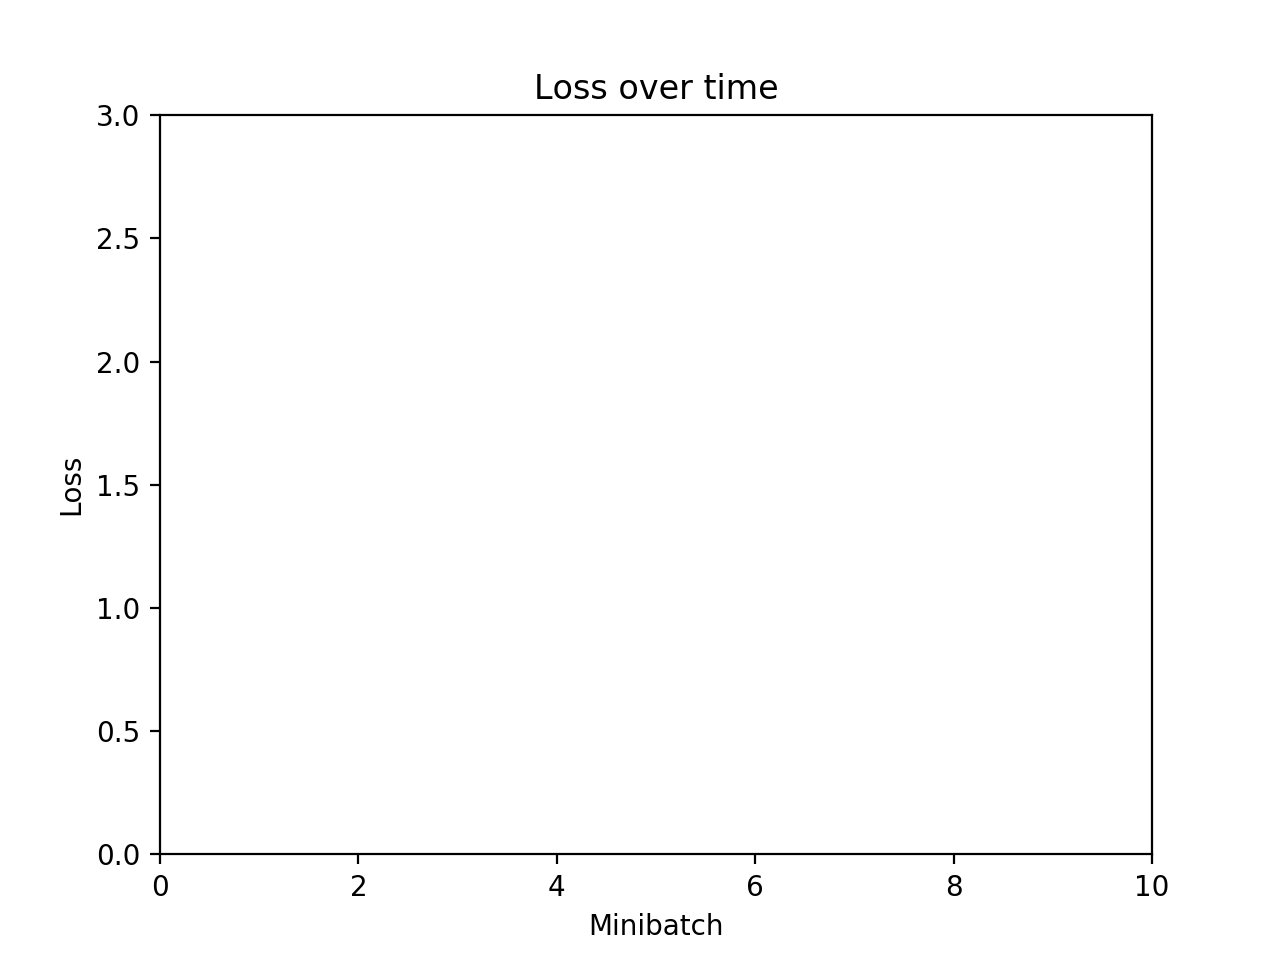

In [66]:
# matplotlib config
loss_values = []
plt.ion()
ax = plt.gca()
ax.set_xlim([0, 10])
ax.set_ylim([0, 3])
plt.title("Loss over time")
plt.xlabel("Minibatch")
plt.ylabel("Loss")
plt.show()

In [67]:
def plot(loss_values):
    ax.set_xlim([0, len(loss_values)+10])
    ax.plot(loss_values)
    plt.draw()
    try:
       plt.pause(0.0001)
    except: pass

## Reading the training data into a list

In [71]:
train_data = open('./data/train.data', 'r').read().strip().split('\n')

In [88]:
import depModel

In [72]:
def train_iter(train_data):
        losses = [] # minibatch loss vector
        random.shuffle(train_data) # shuffle the training data.

        for line in train_data:
            fields = line.strip().split('\t')
            features, label, gold_label = fields[:-1], fields[-1], tag2id(fields[-1])
            result = forward(features)

            # getting loss with respect to negative log softmax function and the gold label; and appending to the minibatch losses.
            loss = dynet.pickneglogsoftmax(result, gold_label)
            losses.append(loss)

            if len(losses) >= minibatch_size:
                minibatch_loss = dynet.esum(losses) / len(losses) # now we have enough loss values to get loss for minibatch
                minibatch_loss.forward() # calling dynetnet to run forward computation for all minibatch items
                minibatch_loss_value = minibatch_loss.value() # getting float value of the loss for current minibatch

                # printing info and plotting
                loss_values.append(minibatch_loss_value)
                
                if len(loss_values)%10==0: plot(loss_values)
                                    
                minibatch_loss.backward() # calling dynetnet to run backpropagation
                updater.update() # calling dynet to change parameter values with respect to current backpropagation

                # empty the loss vector and refresh the memory of dynetnet
                losses = []
                dynet.renew_cg()

        dynet.renew_cg() # there are still some minibatch items in the memory but they are smaller than the minibatch size

# Saving and loading network

In [73]:
def load(filename):
    model.populate(filename)

def save(filename):
    model.save(filename)

# Training epochs

In [75]:
for i in range(7):
    print('epoch', (i+1))
    train_iter(train_data)
    dynet.renew_cg()
print ('finished training!')

epoch 1


NameError: name 'tag2id' is not defined

# Tagging a file

In [ ]:
test_file = 'data/dev.data'
writer = open(test_file+'.output', 'w')
for sentence in open(test_file, 'r'):
    words = sentence.strip().split()
    tags = decode(words)
    output = [word + '\t' + tag for word, tag in zip(words, tags)]
    writer.write('\n'.join(output) + '\n\n')
writer.close()